# Bibliotekos

In [1]:
library(here)
library(tidyverse)
library(plotly)
library(patchwork)
library(zoo)
library(stats)
library(slider)
library(lubridate)
library(scales)
library(RColorBrewer)

Warning message:
"package 'here' was built under R version 4.5.3"
here() starts at C:/Users/crist/Documents/VU, Data Science/6 semestras/Duomenu mokslo projektas/GIT/Duomenu_mokslo_projektas

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'plotly' was built under R version 4.5.3"

Attaching package: 'plotly'


The following object is masked from 'package:ggplot2':

    last_plot


The following object is masked from 'package:stats':

    filter


The following object is masked from 'package:g

# Duomenys

In [2]:
data <- read.csv(here("code", "python",
                      "datasets_prep", "dm_project_dataset.csv"))

data <- data |> rename('time' = observationTime)

data <- data |> dplyr::mutate(time = ymd(time))

In [3]:
str(data)
head(data)

'data.frame':	2772 obs. of  31 variables:
 $ time                                   : Date, format: "2018-07-01" "2018-07-02" ...
 $ absorbing_aerosol_index                : num  -1.016 -0.801 -0.621 -0.659 -1.01 ...
 $ NO2_column_number_density              : num  7.53e-05 7.93e-05 7.70e-05 7.19e-05 7.92e-05 ...
 $ stratospheric_NO2_column_number_density: num  6.18e-05 6.57e-05 6.16e-05 6.54e-05 6.71e-05 ...
 $ NO2_slant_column_number_density        : num  0.000193 0.000196 0.000203 0.000146 0.000198 ...
 $ tropopause_pressure                    : num  22058 22068 19220 19219 19218 ...
 $ H2O_column_number_density              : num  1137 1230 1315 1824 1257 ...
 $ BrO                                    : num  4.38e+13 3.95e+13 4.47e+13 4.89e+13 4.09e+13 ...
 $ BrO_Error                              : num  1.49e+13 1.61e+13 1.50e+13 1.43e+13 1.58e+13 ...
 $ NO2                                    : num  3.63e+15 3.80e+15 4.53e+15 4.15e+15 3.96e+15 ...
 $ NO2_Error                      

,time,absorbing_aerosol_index,NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,H2O_column_number_density,BrO,BrO_Error,NO2,⋯,t2m,airTemperature,seaLevelPressure,relativeHumidity,missforest_precipitation,xgb_cloudCover,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018-07-01,-1.0162473,7.533331e-05,6.183662e-05,0.0001933129,22057.93,1136.782,4.376100e+13,1.489699e+13,3.627587e+15,⋯,12.97028,11.29583,1010.638,72.79167,9.1,89.37500,10.93333,3.762500,13.9,356
2,2018-07-02,-0.8006216,7.926575e-05,6.572057e-05,0.0001963793,22067.76,1229.532,3.946727e+13,1.611675e+13,3.795988e+15,⋯,14.77985,10.86667,1006.663,94.00000,11.9,91.50000,10.42917,2.516667,7.0,327
3,2018-07-03,-0.6212348,7.699571e-05,6.164219e-05,0.0002032877,19219.67,1314.681,4.465846e+13,1.499280e+13,4.526218e+15,⋯,15.96597,13.38750,1008.454,90.04167,10.0,89.37500,13.38750,2.537500,8.3,271
4,2018-07-04,-0.6591799,7.192521e-05,6.535854e-05,0.0001463974,19219.45,1824.428,4.888972e+13,1.430855e+13,4.149200e+15,⋯,18.01572,13.59167,1009.237,88.29167,13.9,88.33333,13.59167,2.358333,8.7,288
5,2018-07-05,-1.0102344,7.921198e-05,6.705435e-05,0.0001983014,19218.37,1257.064,4.093649e+13,1.583584e+13,3.959891e+15,⋯,19.04031,16.29167,1008.079,70.20833,0.0,66.00000,16.29167,1.283333,6.1,293
6,2018-07-06,-1.1754774,8.286563e-05,6.885977e-05,0.0001936762,19223.54,1455.858,2.298473e+13,1.981660e+13,3.959520e+15,⋯,19.61520,17.68750,1008.171,68.16667,0.0,51.33333,17.68750,3.108333,10.4,275


In [4]:
summary(data)

      time            absorbing_aerosol_index NO2_column_number_density
 Min.   :2018-07-01   Min.   :-2.9906         Min.   :2.731e-06        
 1st Qu.:2020-05-23   1st Qu.:-1.1384         1st Qu.:6.528e-05        
 Median :2022-04-16   Median :-0.6556         Median :7.640e-05        
 Mean   :2022-04-16   Mean   :-0.7188         Mean   :7.869e-05        
 3rd Qu.:2024-03-09   3rd Qu.:-0.2885         3rd Qu.:8.655e-05        
 Max.   :2026-01-31   Max.   : 3.0692         Max.   :4.994e-04        
 stratospheric_NO2_column_number_density NO2_slant_column_number_density
 Min.   :7.724e-06                       Min.   :6.039e-05              
 1st Qu.:2.524e-05                       1st Qu.:1.533e-04              
 Median :4.184e-05                       Median :1.739e-04              
 Mean   :4.174e-05                       Mean   :1.728e-04              
 3rd Qu.:5.750e-05                       3rd Qu.:1.925e-04              
 Max.   :8.146e-05                       Max.   :3.357e-04

# Sezoniškumas

## Ar tarša pasižymi sezoniškumu?

In [5]:
season_shift_plot <- function(data, var, name) {
  # my_palette <- colorRampPalette(brewer.pal(8, "Blues"))(9)

  base_cols <- RColorBrewer::brewer.pal(9, "Blues")
  dark_cols <- base_cols[5:9]  # tik tamsesnė pusė

  my_palette <- colorRampPalette(dark_cols)(9)

  offset_val <- max(data[[var]], na.rm = TRUE) * 0.5

  plot_data <- data |> 
    mutate(
      date_overlay = update(time, year = 2000),
      year = factor(year(time)),
      year_index = as.numeric(year) - 1,
      vertical_shift = year_index * offset_val
    )

  avg_seasonal <- data |>
    mutate(date_overlay = update(time, year = 2000)) |>
    group_by(date_overlay) |>
    summarize(mean_val = mean(.data[[var]], na.rm = TRUE), .groups = "drop")

  background_data <- tidyr::expand_grid(
    avg_seasonal, 
    year = unique(plot_data$year)
  ) |>
    mutate(
      year_index = as.numeric(year) - 1,
      vertical_shift = year_index * offset_val
    )

  ggplot() +
    geom_line(
      data = background_data, 
      aes(x = date_overlay, y = mean_val + vertical_shift, group = year), 
      color = "grey70", linewidth = 0.5, alpha = 0.8
    ) +
    geom_line(
      data = plot_data, 
      aes(x = date_overlay, y = .data[[var]] + vertical_shift, color = year), 
      linewidth = 0.4
    ) +
    scale_x_date(date_labels = "%b") +
    scale_color_manual(values = my_palette) +
    scale_x_date(date_labels = "%m", date_breaks = "1 month", expand = expansion(mult = 0, add = 0) ) +
    theme_bw() + 
    theme(axis.title.x = element_text(size = 8),
        # legend.position = "none",
        # legend.justification = c("right", "top"),
        # legend.background = element_rect(fill = "white", color = "black", linewidth = 0.1),
        # legend.box = "horizontal",
        # legend.direction = "horizontal",
        # legend.margin = margin(2, 2, 2, 2),
        # legend.box.margin = margin(0, 0, 0, 0),
        plot.title = element_text(size = 10, hjust = 0.5),
        plot.subtitle = element_text(size = 8),
        legend.text = element_text(size = 8),
        legend.key.size = unit(0.3, "cm"),
        axis.ticks.y = element_blank(),
      axis.text.y = element_blank(),
      axis.text.x = element_text(size = 6)) +
    labs(x = NULL, y = NULL, color = "Metai", title = name)
}

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


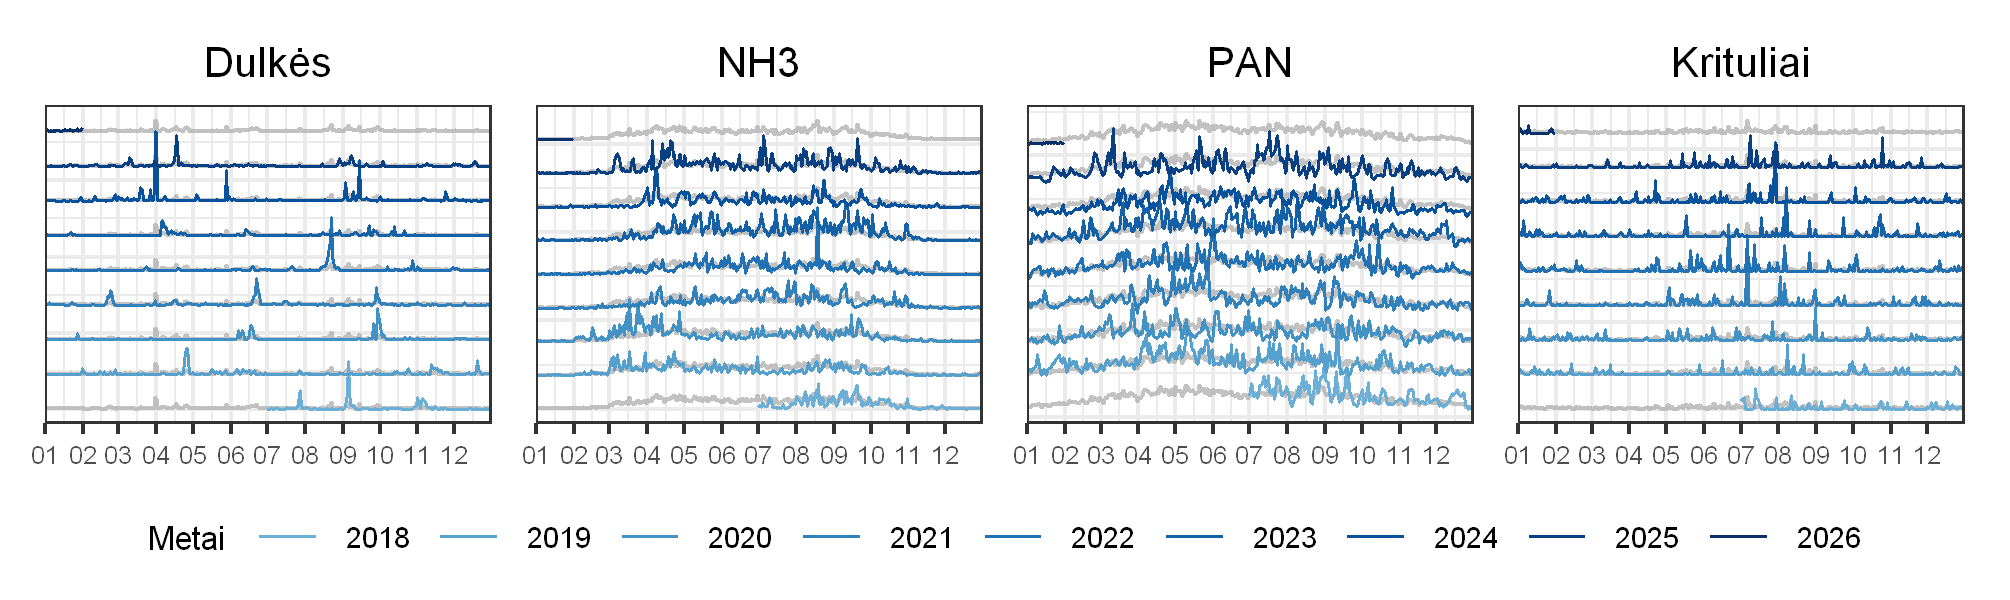

In [6]:
options(repr.plot.width = 6.7, repr.plot.height = 2, repr.plot.res = 300)

p1 <- season_shift_plot(data, 'dust', 'Dulkės') + theme(legend.position = "none")
p2 <- season_shift_plot(data, 'nh3', 'NH3') + theme(legend.position = "none")
p3 <- season_shift_plot(data, 'pans', 'PAN') + theme(legend.position = "none")
p4 <- season_shift_plot(data, 'missforest_precipitation', 'Krituliai') + theme(legend.position = "none")

combined <- p1 | p2 | p3 | p4

wrap_plots(
  combined,
  guides = "collect"
) +
  plot_layout(guides = "collect") &
  theme(
    legend.margin = margin(0, 0, 0, 0),
    legend.box.margin = margin(0, 0, 0, 0),
    legend.position = "bottom",
    legend.justification = "center",
    legend.direction = "horizontal",
    legend.box = "horizontal",
    legend.box.just = "center",
    legend.key.width = unit(0.6, "cm"),
    legend.spacing.x = unit(1, "cm"),
    legend.text = element_text(size = 7),
    legend.title = element_text(size = 8)
  ) &
  guides(
    color = guide_legend(nrow = 1),
    fill  = guide_legend(nrow = 1)
  )

ggsave(filename = "seasonal_shift_4.png", width = 6.7,
       height = 2, units = "in", dpi = 300)

## Sezoniškumas pagal SD

In [7]:
season_sd_plot <- function(data, var_name) {
  var_label <- deparse(substitute(var_name))
  
  p <- data %>%
  mutate(
    date_overlay = update(time, year = 2000)
  ) %>%
  group_by(date_overlay) %>%
  summarize(
    mean_no2 = mean({{ var_name }}, na.rm = TRUE),
    sd_no2 = sd({{ var_name }}, na.rm = TRUE)
  ) %>%
  ggplot(aes(x = date_overlay, y = mean_no2)) +
  geom_line(color = "red", linewidth = 0.5) +
  geom_ribbon(aes(ymin = mean_no2 - sd_no2, ymax = mean_no2 + sd_no2), alpha = 0.2) +
  scale_x_date(date_labels = "%m", date_breaks = "1 month", expand = expansion(mult = 0, add = 0) ) +
  # scale_x_date(date_labels = "%b %d") +
  theme_bw() +
  labs(y = var_label, x = NULL)
  
  return(p)
}

In [175]:
get_seasonal_cv <- function(data, var_name, window_size = 30) {
  
  data |>
    mutate(doy = yday(time)) |>
    group_by(doy) |>
    summarize(
      mu = mean({{ var_name }}, na.rm = TRUE),
      sigma = sd({{ var_name }}, na.rm = TRUE),
      .groups = "drop"
    ) |>
    mutate(
      cv = ifelse(abs(mu) > 0, sigma / abs(mu), NA)
    ) |>
    mutate(
      roll_cv = slide_dbl(cv, mean, .before = window_size, .complete = FALSE)
    ) |>
    mutate(date_overlay = as.Date(paste0("2000-", doy), format = "%Y-%j"))
}

rolling_cv_plot <- function(data, var_name, top_name = FALSE) {
  var_label <- deparse(substitute(var_name))
  
  cv_data <- get_seasonal_cv(data, {{ var_name }}, window_size = 15)
  
  p2 <- ggplot(cv_data, aes(x = date_overlay, y = roll_cv)) +
    geom_line(color = "darkgreen", linewidth = 0.6) +
    scale_x_date(date_labels = "%m", date_breaks = "1 month", expand = expansion(mult = 0, add = 0) ) +
    scale_y_continuous(labels = label_number(decimal.mark = ",")) +
    theme_bw() +
    labs(y = "Slenkantis CV", x = NULL) +
    theme(axis.title.y = element_text(size = 6),
        axis.title.x = element_text(size = 6),
        legend.position = c(0.98, 0.98),
        legend.justification = c("right", "top"),
        legend.background = element_rect(fill = "white", color = "black", linewidth = 0.1),
        legend.box = "horizontal",
        legend.direction = "horizontal",
        legend.margin = margin(2, 2, 2, 2),
        legend.box.margin = margin(0, 0, 0, 0),
        plot.title = element_text(size = 8),
        plot.subtitle = element_text(size = 8),
        legend.text = element_text(size = 8),
        legend.key.size = unit(0.3, "cm"),
        axis.text.x = element_text(size = 6),
        axis.text.y = element_text(size = 6))
  
  return(p2)
}

season_rolling_sd_plot <- function(data, var_name, top_name = FALSE, y_scale = FALSE, title = "NULL") {
  var_label <- deparse(substitute(var_name))
  
  p1 <- data |>
  mutate(
    date_overlay = update(time, year = 2000)
  ) |>
  group_by(date_overlay) |>
  summarize(
    mean_no2 = mean({{ var_name }}, na.rm = TRUE),
    sd_no2 = sd({{ var_name }}, na.rm = TRUE)
  ) |>
  ggplot(aes(x = date_overlay, y = mean_no2)) +
  geom_line(color = "red", linewidth = 0.3) +
  geom_ribbon(aes(ymin = mean_no2 - sd_no2, ymax = mean_no2 + sd_no2), alpha = 0.2) +
  scale_x_date(date_labels = "%m", date_breaks = "1 month", expand = expansion(mult = 0, add = 0) ) +
  scale_y_continuous(
  labels = function(x) {
    scientific <- scales::scientific_format(digits = 2)(x)
    scientific <- gsub("e", " %*% 10^", scientific)
    scientific <- gsub("\\+", "", scientific)
    parse(text = scientific)
  }
) +
theme_bw() +
  theme(axis.title.y = element_text(size = 6),
        axis.title.x = element_text(size = 8),
        legend.position = c(0.98, 0.98),
        legend.justification = c("right", "top"),
        legend.background = element_rect(fill = "white", color = "black", linewidth = 0.1),
        legend.box = "horizontal",
        legend.direction = "horizontal",
        legend.margin = margin(0, 0, 0, 0),
        legend.box.margin = margin(0, 0, 0, 0),
        plot.title = element_text(size = 8, margin = margin(t = 2, b = 0)),
        plot.subtitle = element_text(size = 8),
        legend.text = element_text(size = 8),
        legend.key.size = unit(0.3, "cm"),
        axis.text.x = element_text(size = 7),
        axis.text.y = element_text(size = 6))
  
  if (top_name) {
    p1 <- p1 + labs(title = var_label, x = NULL, y = NULL)
  } else {
    p1 <- p1 + labs(y = var_label, x = NULL)
  }

  if (title != "NULL") {
    p1 <- p1 + labs(title = title)
  }

  if (y_scale) {
    p1 <- p1 + scale_y_continuous(labels = label_number(scale = 1e-13, accuracy = 1, decimal.mark = ","))
    if (top_name) {
    p1 <- p1 + labs(title = paste(var_label, "(1x10^13)"), x = NULL, y = NULL)
  } else {
    p1 <- p1 + labs(y = paste(var_label, "(1x10^13)"), x = NULL)
  }
  }
  
  p2 <- rolling_cv_plot(data, {{ var_name }})
  
  return(p1+p2)
}

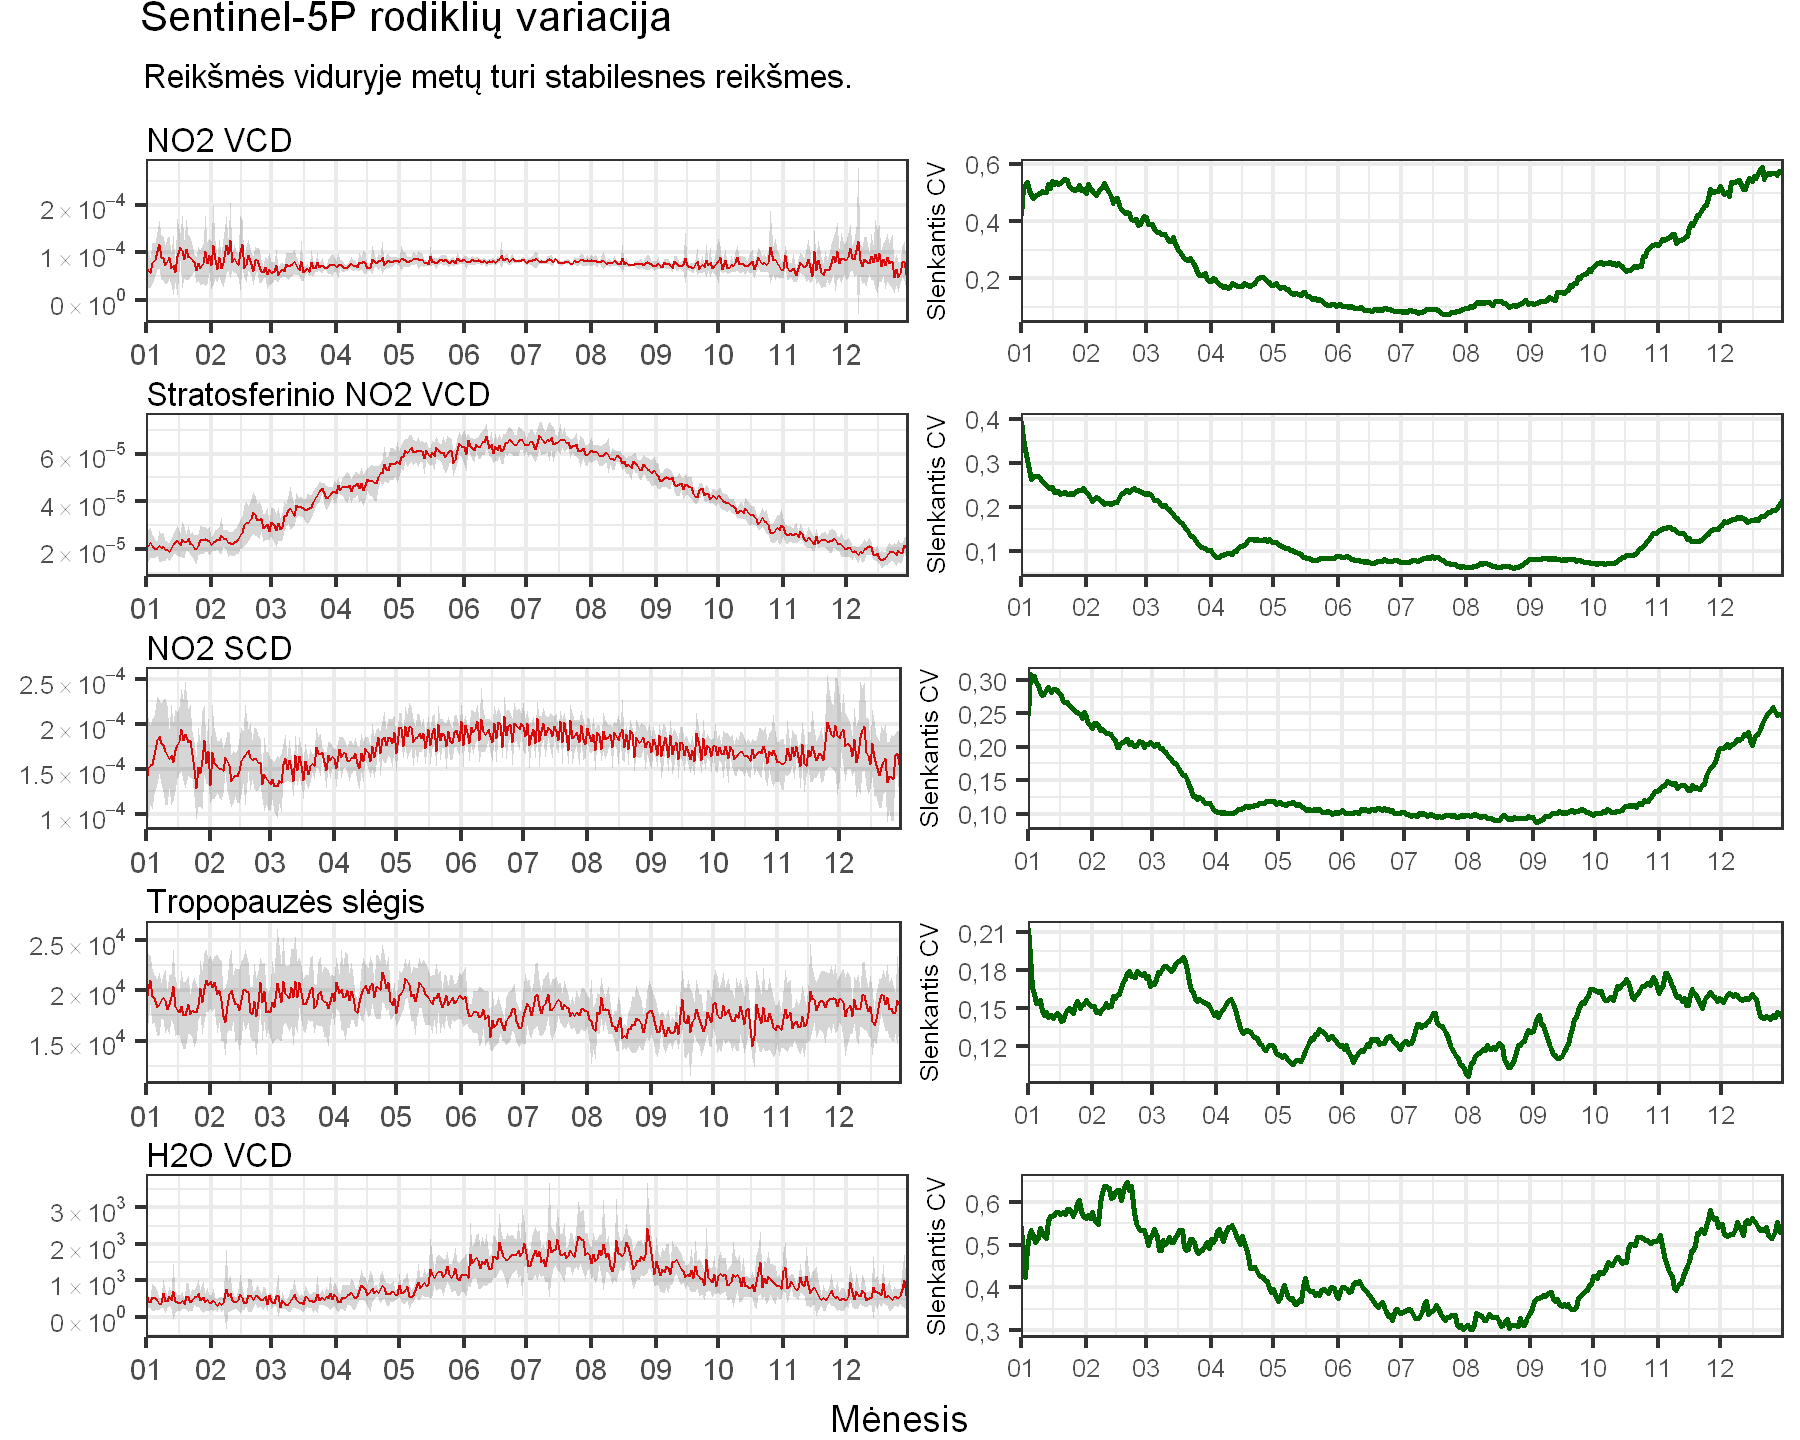

In [176]:
options(repr.plot.width = 6, repr.plot.height = 4.8, repr.plot.res = 300)

#season_rolling_sd_plot(data, absorbing_aerosol_index, TRUE) /
seasonal_cv_s5p_plot <- season_rolling_sd_plot(data, NO2_column_number_density, TRUE, FALSE, "NO2 VCD") /
season_rolling_sd_plot(data, stratospheric_NO2_column_number_density, TRUE, title = "Stratosferinio NO2 VCD") /
season_rolling_sd_plot(data, NO2_slant_column_number_density, TRUE, title = "NO2 SCD") /
season_rolling_sd_plot(data, tropopause_pressure, TRUE, title = "Tropopauzės slėgis") /
season_rolling_sd_plot(data, H2O_column_number_density, TRUE, title = "H2O VCD") + 
plot_annotation(
  title = 'Sentinel-5P rodiklių variacija',
  subtitle = 'Reikšmės viduryje metų turi stabilesnes reikšmes.',
    caption = 'Mėnesis',
  theme = theme(plot.title = element_text(size = 10, hjust = 0.1),
plot.subtitle = element_text(size = 8, hjust = 0.12), 
plot.caption = element_text(size = 9, hjust = 0.5, margin = margin(t = 4)) )
)+ plot_layout(heights = c(1,1,1,1,1), guides = "collect") & theme(plot.margin = margin(0, 2, 0, 2))

seasonal_cv_s5p_plot

ggsave(filename = "seasonal_cv_s5p_plot.png", width = 6,
  height = 4.8, units = "in",
  dpi = 300)

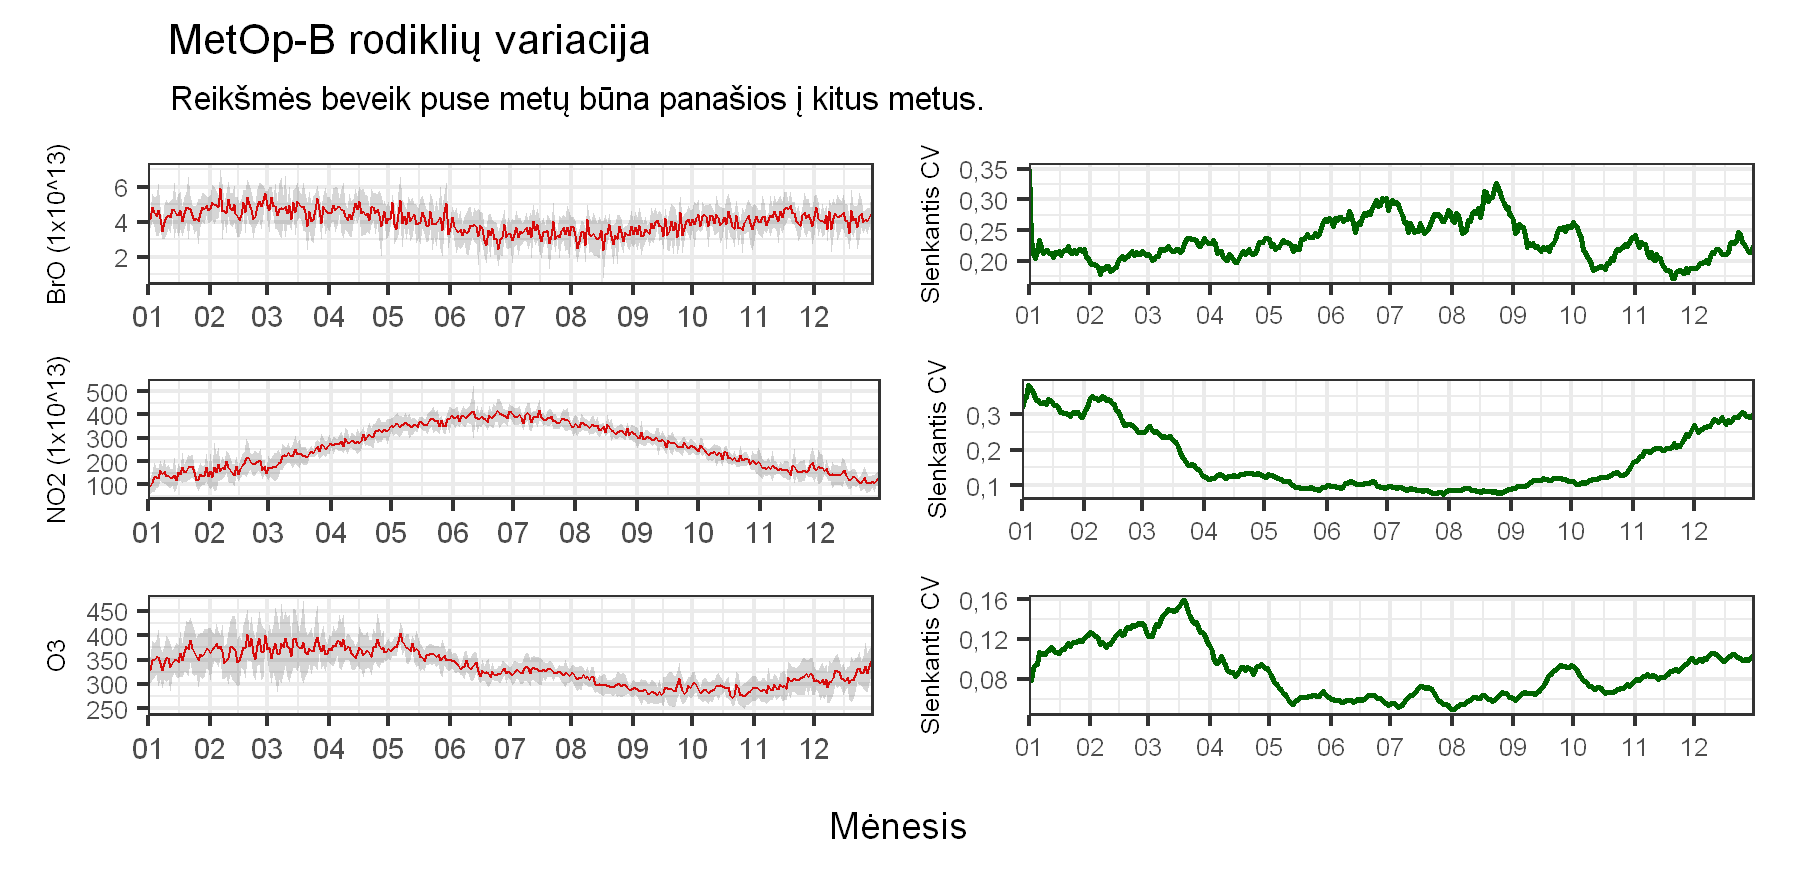

In [10]:
options(repr.plot.width = 6, repr.plot.height = 2.9, repr.plot.res = 300)

seasonal_cv_metop_plot <- season_rolling_sd_plot(data, BrO, y_scale = TRUE) /
season_rolling_sd_plot(data, NO2, y_scale = TRUE) /
season_rolling_sd_plot(data, O3) + plot_annotation(
  title = 'MetOp-B rodiklių variacija',
  subtitle = 'Reikšmės beveik puse metų būna panašios į kitus metus.',
  caption = 'Mėnesis' 
) & 
theme(plot.title = element_text(size = 10, hjust = 0.1),
  plot.subtitle = element_text(size = 8, hjust = 0.14),
  plot.caption = element_text(size = 9, hjust = 0.5)
  )

seasonal_cv_metop_plot

ggsave(filename = "seasonal_cv_metop_plot.png", width = 6,
  height = 2.8, units = "in",
  dpi = 300)

## Paskisirstymas pagal mėnesį

Warning message:
"Orientation is not uniquely specified when both the x and y aesthetics are
continuous. Picking default orientation 'x'."
Warning message:
"Orientation is not uniquely specified when both the x and y aesthetics are
continuous. Picking default orientation 'x'."


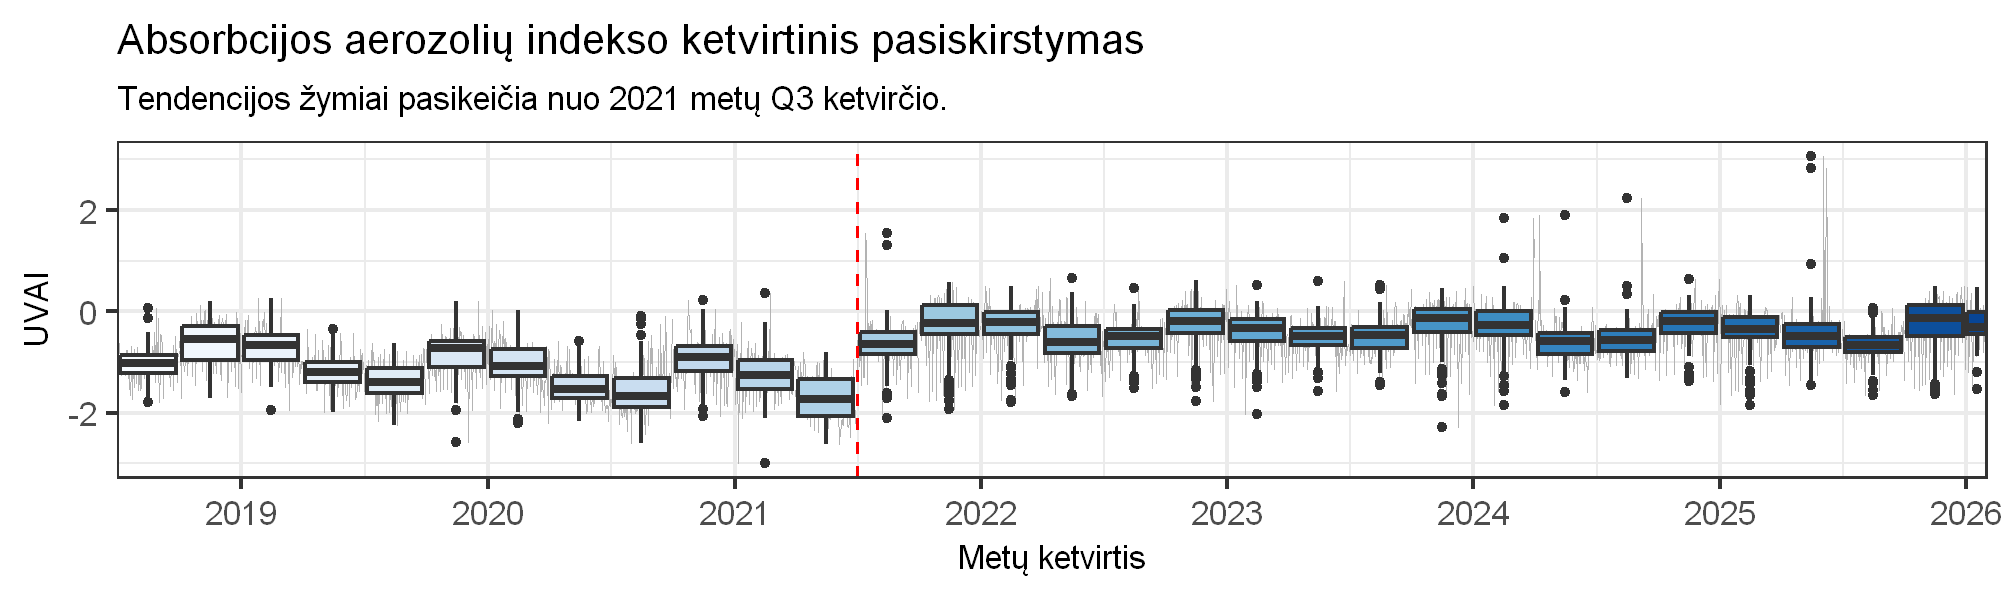

In [11]:
options(repr.plot.width = 6.7, repr.plot.height = 2, repr.plot.res = 300)

n_groups <- length(unique(floor_date(data$time, unit = "quarter")))
my_palette <- colorRampPalette(brewer.pal(8, "Blues"))(n_groups)

the_box_plot <- data |> 
mutate(month_group = floor_date(time, unit = "quarter")) |> 
ggplot(aes(x = time, y = absorbing_aerosol_index, fill = as.factor(month_group))) +
    geom_line(linewidth = 0.1, color = 'grey70') +
    geom_boxplot(show.legend = FALSE, outlier.size = 0.8) +
    geom_vline(xintercept = as.Date("2021-07-01"), color = 'red', linewidth = 0.4, linetype = 'dashed') +
    scale_fill_manual(values = my_palette) +
    scale_x_date(date_labels = "%Y", date_breaks = "1 year", expand = expansion(mult = 0, add = 0) ) +
    labs(title = "Absorbcijos aerozolių indekso ketvirtinis pasiskirstymas",
        subtitle = "Tendencijos žymiai pasikeičia nuo 2021 metų Q3 ketvirčio.",
        x = "Metų ketvirtis",
        y = "UVAI") +
    theme_bw() +
    theme(axis.title.y = element_text(size = 8),
        axis.title.x = element_text(size = 8),
        legend.position = c(0.98, 0.98),
        legend.justification = c("right", "top"),
        legend.background = element_rect(fill = "white", color = "black", linewidth = 0.1),
        legend.box = "horizontal",
        legend.direction = "horizontal",
        legend.margin = margin(0, 2, 0, 2),
        legend.box.margin = margin(0, 0, 0, 0),
        plot.title = element_text(size = 10),
        plot.subtitle = element_text(size = 8),
        legend.text = element_text(size = 8),
        legend.key.size = unit(0.3, "cm"),
        axis.text.x = element_text(size = 8),
        axis.text.y = element_text(size = 8))

the_box_plot

ggsave(filename = "the_box_plot.png", width = 6.7,
  height = 2, units = "in",
  dpi = 300)

In [12]:
data |> select(time, absorbing_aerosol_index) |> arrange(absorbing_aerosol_index) |> tail(10)

,time,absorbing_aerosol_index
,<date>,<dbl>
2763,2022-04-13,0.6661113
2764,2025-06-08,0.9386920
2765,2024-03-31,1.0573499
2766,2021-07-15,1.3120427
2767,2021-07-14,1.5433202
2768,2024-03-30,1.8494785
2769,2024-04-08,1.8983029
2770,2024-09-06,2.2396243
2771,2025-06-07,2.8275366


## Ar bent vieno MetOp rodiklio paklaida kinta ar yra pastovi?

### BrO

In [101]:
p_BrO_error <- data |>
  ggplot(aes(x = time, y = BrO) ) +
  geom_ribbon(aes(ymin = BrO - BrO_Error, ymax = BrO + BrO_Error, fill = "Paklaida"), alpha = 0.5) +
  geom_line(aes(color = "BrO"), linewidth = 0.22, alpha = 0.9) +
  scale_x_date(date_labels = "%Y", date_breaks = "1 year", expand = expansion(mult = 0, add = 0) ) +
  scale_y_continuous(
    labels = label_number(scale = 1e-13, accuracy = 0.1, decimal.mark = ",")
  ) +
  scale_fill_manual(values = c("Paklaida" = "red")) +
  scale_color_manual(values = c("BrO" = "gold")) +
  theme_bw() +
  theme(axis.title.y = element_text(size = 8),
        legend.position = c(0.98, 0.98),
        legend.justification = c("right", "top"),
        legend.background = element_rect(fill = "white", color = "black", linewidth = 0.1),
        legend.box = "horizontal",
        legend.direction = "horizontal",
        legend.margin = margin(2, 2, 2, 2),
        legend.box.margin = margin(0, 0, 0, 0),
        plot.title = element_text(size = 10),
        plot.subtitle = element_text(size = 8),
        legend.text = element_text(size = 8),
        legend.key.size = unit(0.3, "cm"),
        axis.text.x = element_text(size = 8),
        axis.text.y = element_text(size = 8)) +
  labs(title = "BrO vidutinės mėn. paklaidos sezoniškumas",
       y = expression(atop(BrO ~ koncentracija ~ (10^{13}), molec/cm^{2})),
       x = NULL,
       subtitle = "Šaltuoju periodu paklaida vidutiniškai mažiausia. Didžiausia Q3 ketvirtyje.",
       fill = NULL, 
       color = NULL)

In [83]:
df_Br_plot <- data |>
  mutate(month_group = floor_date(time, unit = "month") ) |>
  mutate(BrO_global_mean = mean(BrO, na.rm = TRUE)) |> 
  group_by(month_group) |>
  mutate(
    BrO_month_avg = mean(BrO, na.rm = TRUE),
    BrO_error_month_avg = mean(BrO_Error, na.rm = TRUE),
    adjustment = BrO_global_mean - BrO_month_avg,
    BrO_centered = BrO_month_avg + adjustment
  ) |>
  ungroup() |>
  select(-month_group, -BrO_global_mean, -adjustment)

seasonal_summary <- data |>
  mutate(season = quarter(time) ) |>
  group_by(season) |>
  summarise(
    avg_BrO = mean(BrO, na.rm = TRUE),
    avg_Error = mean(BrO_Error, na.rm = TRUE)
  ) |>
  mutate(Br_CV = avg_Error / avg_BrO)


CV_values <- seasonal_summary$Br_CV |> round(2)
fmt <- function(x) gsub("\\.", ",", sprintf("%.2f", x))
CV_values <- fmt(seasonal_summary$Br_CV)

p_BrO_error_avg <- df_Br_plot |>
  ggplot(aes(x = time, y = BrO_centered)) +
  geom_ribbon(aes(ymin = BrO_centered - BrO_error_month_avg, ymax = BrO_centered + BrO_error_month_avg), alpha = 0.5, fill = 'gold') +
  geom_line(color = "red", linewidth = 0.1, linetype = 'dashed') +
  scale_x_date(date_labels = "%Y", date_breaks = "1 year", expand = expansion(mult = 0, add = 0)) +
  theme_bw() +
  theme(axis.title.y = element_text(size = 8),
        axis.title.x = element_text(size = 8),
        plot.subtitle = element_text(size = 8, face = "bold"),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.text.x = element_text(size = 8)) +
  labs(y = "Centruota\npaklaida",
       x = "Metai",
       subtitle = paste("CV: Q1=", CV_values[1],
                        ", Q2=", CV_values[2],
                        ", Q3=", CV_values[3],
                        ", Q4=", CV_values[4], sep = ""))

rm(df_Br_plot)

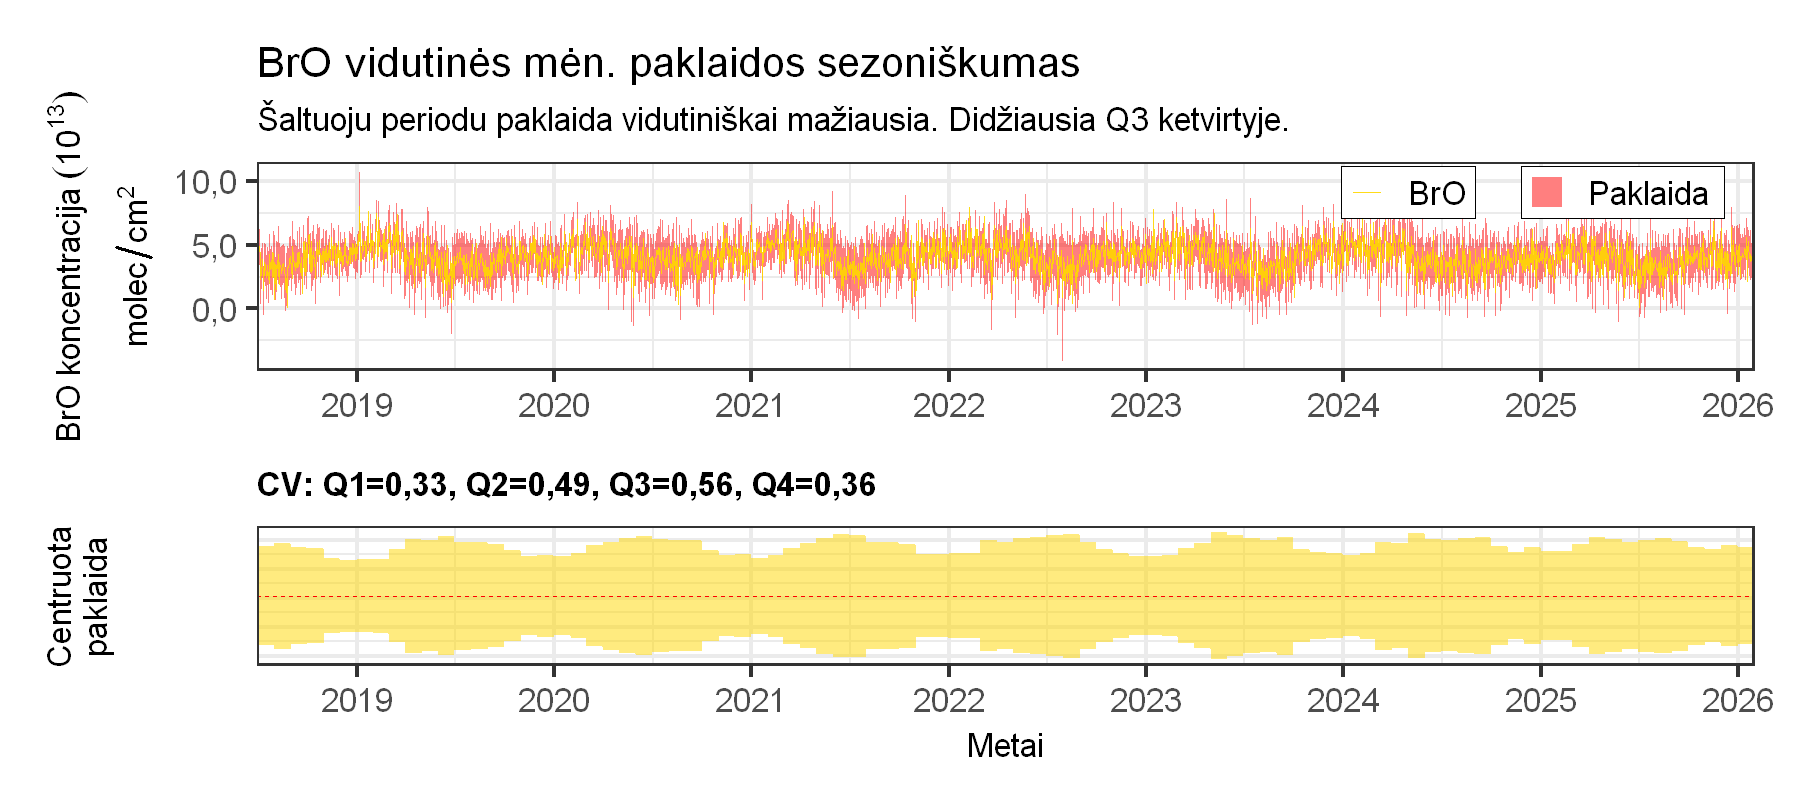

In [102]:
options(repr.plot.width = 6, repr.plot.height = 2.7, repr.plot.res = 300)

gg_final_bro <- p_BrO_error / p_BrO_error_avg +
  plot_layout(heights = c(3, 2))
gg_final_bro

ggsave(filename = "gg_final_bro.png", width = 6,
  height = 2.7, units = "in",
  dpi = 300)

### NO2

In [103]:
p_NO2_error <- data |>
  ggplot(aes(x = time, y = NO2) ) +
  geom_ribbon(aes(ymin = NO2 - NO2_Error, ymax = NO2 + NO2_Error, fill = "Paklaida"), alpha = 0.5) +
  geom_line(aes(color = "NO2"), linewidth = 0.22, alpha = 0.9) +
  scale_x_date(date_labels = "%Y", date_breaks = "1 year", expand = expansion(mult = 0, add = 0) ) +
  scale_y_continuous(
    labels = label_number(scale = 1e-15, accuracy = 0.1, decimal.mark = ",")
  ) +
  scale_fill_manual(values = c("Paklaida" = "red")) +
  scale_color_manual(values = c("NO2" = "lightgreen")) +
  theme_bw() +
  theme(axis.title.y = element_text(size = 8),
        legend.position = c(0.98, 0.98),
        legend.justification = c("right", "top"),
        legend.background = element_rect(fill = "white", color = "black", linewidth = 0.1),
        legend.box = "horizontal",
        legend.direction = "horizontal",
        legend.margin = margin(2, 2, 2, 2),
        legend.box.margin = margin(0, 0, 0, 0),
        plot.title = element_text(size = 10),
        plot.subtitle = element_text(size = 8),
        legend.text = element_text(size = 8),
        legend.key.size = unit(0.3, "cm"),
        axis.text.x = element_text(size = 8),
        axis.text.y = element_text(size = 8)) +
  labs(title = "NO2 vidutinės mėn. paklaidos sezoniškumas",
       y = expression(atop(NO[2] ~ koncentracija ~ (10^{15}), molec/cm^{2})),
       x = NULL,
       subtitle = "NO2 paklaida pastovi (CV 11-13 %).",
       fill = NULL, 
       color = NULL)

In [85]:
df_NO2_plot <- data |>
  mutate(month_group = floor_date(time, unit = "month")) |>
  mutate(NO2_global_mean = mean(NO2, na.rm = TRUE)) |>
  group_by(month_group) |>
  mutate(
    NO2_month_avg = mean(NO2, na.rm = TRUE),
    NO2_error_month_avg = mean(NO2_Error, na.rm = TRUE),
    adjustment = NO2_global_mean - NO2_month_avg,
    NO2_centered = NO2_month_avg + adjustment
  ) |>
  ungroup() |>
  select(-month_group, -NO2_global_mean, -adjustment)

seasonal_summary <- data |>
  mutate(season = quarter(time) ) |>
  group_by(season) |>
  summarise(
    avg_NO2 = mean(NO2, na.rm = TRUE),
    avg_Error = mean(NO2_Error, na.rm = TRUE)
  ) |>
  mutate(NO2_CV = avg_Error / avg_NO2)

CV_values <- seasonal_summary$NO2_CV |> round(2)
fmt <- function(x) gsub("\\.", ",", sprintf("%.2f", x))
CV_values <- fmt(seasonal_summary$NO2_CV)

p_NO2_error_avg <- df_NO2_plot |>
  ggplot(aes(x = time, y = NO2_centered)) +
  geom_ribbon(
              aes(ymin = NO2_centered - NO2_error_month_avg,
                  ymax = NO2_centered + NO2_error_month_avg),
              alpha = 0.5, fill = "lightgreen") +
  geom_line(color = "red", linewidth = 0.1, linetype = "dashed") +
  scale_x_date(date_labels = "%Y", date_breaks = "1 year",
               expand = expansion(mult = 0, add = 0)) +
  theme_bw() +
  theme(axis.title.y = element_text(size = 8),
        axis.title.x = element_text(size = 8),
        plot.subtitle = element_text(size = 8, face = "bold"),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.text.x = element_text(size = 8)) +
  labs(y = "Centruota\npaklaida",
       x = "Metai",
       subtitle = paste("CV: Q1=", CV_values[1],
                        ", Q2=", CV_values[2],
                        ", Q3=", CV_values[3],
                        ", Q4=", CV_values[4], sep = ""))

rm(df_NO2_plot)

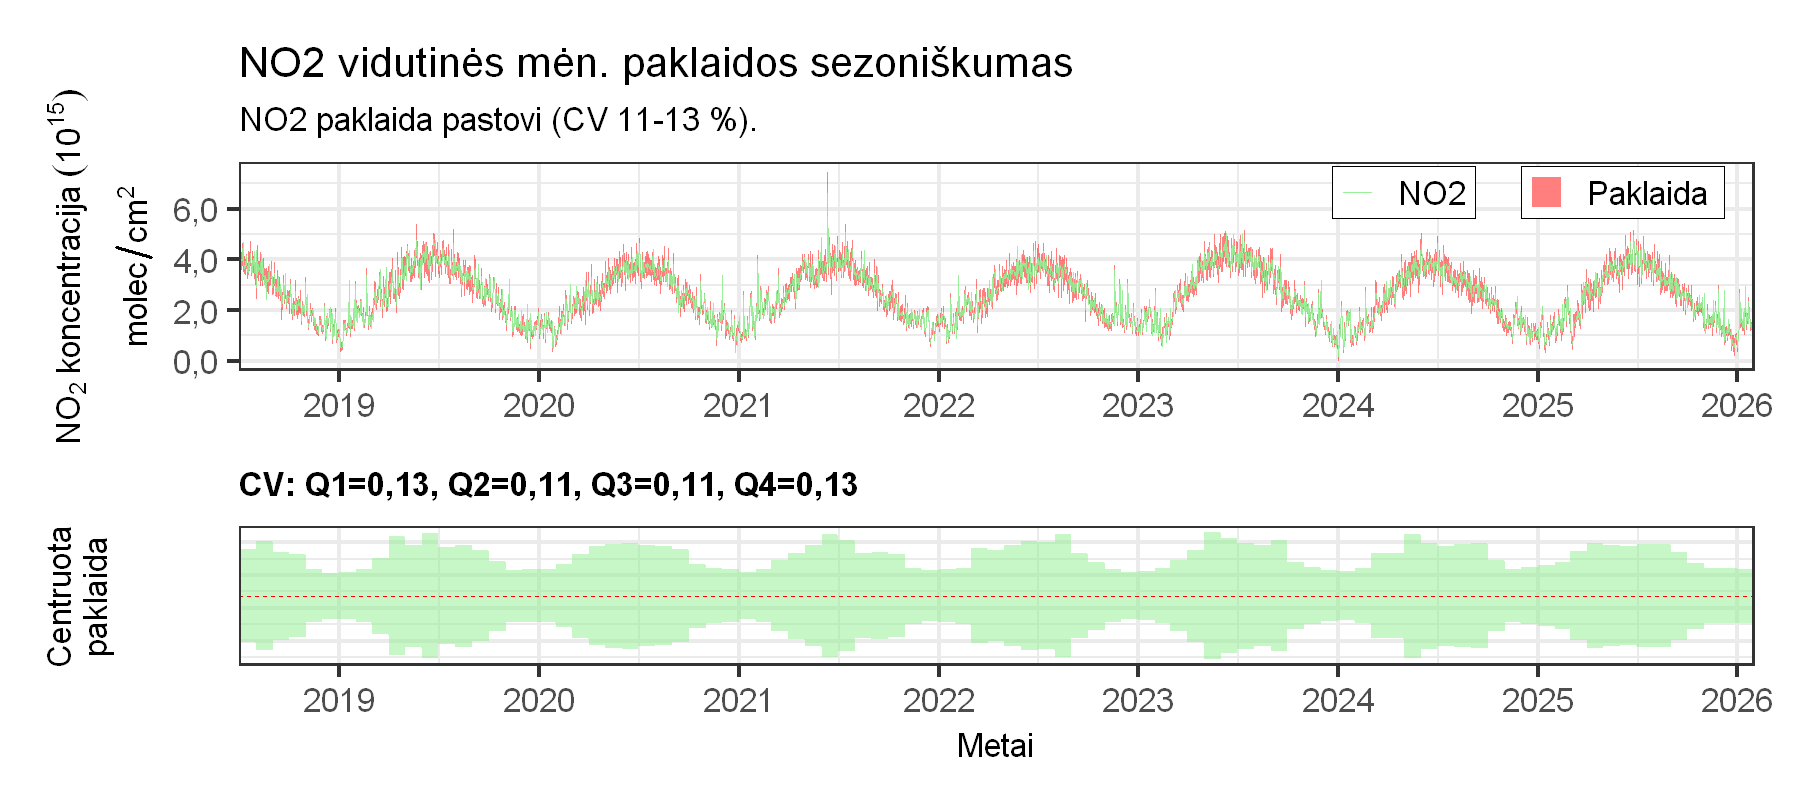

In [104]:
options(repr.plot.width = 6, repr.plot.height = 2.7, repr.plot.res = 300)

gg_final_no2 <- p_NO2_error / p_NO2_error_avg +
  plot_layout(heights = c(3, 2))

gg_final_no2

ggsave(filename = "gg_final_no2.png", width = 6,
  height = 2.7)

### O3

In [105]:
p_O3_error <- data |>
  ggplot(aes(x = time, y = O3) ) +
  geom_ribbon(aes(ymin = O3 - O3_Error,
                  ymax = O3 + O3_Error, fill = "Paklaida")) +
  geom_line(aes(color = "O3"), linewidth = 0.22, alpha = 0.6) +
  scale_x_date(date_labels = "%Y", date_breaks = "1 year",
               expand = expansion(mult = 0, add = 0)) +
  scale_y_continuous(
    labels = label_number(decimal.mark = ",")
  ) +
  scale_fill_manual(values = c("Paklaida" = "red")) +
  scale_color_manual(values = c("O3" = "lightblue")) +
  theme_bw() +
  theme(axis.title.y = element_text(size = 8),
        legend.position = c(0.98, 0.98),
        legend.justification = c("right", "top"),
        legend.background = element_rect(fill = "white", color = "black", linewidth = 0.1),
        legend.box = "horizontal",
        legend.direction = "horizontal",
        legend.margin = margin(2, 2, 2, 2),
        legend.box.margin = margin(0, 0, 0, 0),
        plot.title = element_text(size = 10),
        plot.subtitle = element_text(size = 8),
        legend.text = element_text(size = 8),
        legend.key.size = unit(0.3, "cm"),
        axis.text.x = element_text(size = 8),
        axis.text.y = element_text(size = 8)) +
  labs(title = "O3 vidutinės mėn. paklaidos sezoniškumas",
       y = expression(atop(O[3] ~ koncentracija, DU)),
       x = NULL,
       subtitle = "O3 paklaida minimali (CV < 1%).",
       fill = NULL, 
       color = NULL)

In [87]:
df_O3_plot <- data |>
  mutate(month_group = floor_date(time, unit = "month") ) |>
  mutate(O3_global_mean = mean(O3, na.rm = TRUE)) |> 
  group_by(month_group) |>
  mutate(
    O3_month_avg = mean(O3, na.rm = TRUE),
    O3_error_month_avg = mean(O3_Error, na.rm = TRUE),
    adjustment = O3_global_mean - O3_month_avg,
    O3_centered = O3_month_avg + adjustment
  ) |>
  ungroup() |>
  select(-month_group, -O3_global_mean, -adjustment)

seasonal_summary <- data |>
  mutate(season = quarter(time) ) |>
  group_by(season) |>
  summarise(
    avg_O3 = mean(O3, na.rm = TRUE),
    avg_Error = mean(O3_Error, na.rm = TRUE)
  ) |>
  mutate(O3_CV = avg_Error / avg_O3)

CV_values <- seasonal_summary$O3_CV |> round(2)
fmt <- function(x) gsub("\\.", ",", sprintf("%.2f", x))
CV_values <- fmt(seasonal_summary$O3_CV)

p_O3_error_avg <- df_O3_plot |>
  ggplot(aes(x = time, y = O3_centered)) +
  geom_ribbon(
              aes(ymin = O3_centered - O3_error_month_avg,
                  ymax = O3_centered + O3_error_month_avg),
              alpha = 0.5, fill = "lightblue") +
  geom_line(color = "red", linewidth = 0.1, linetype = "dashed") +
  scale_x_date(date_labels = "%Y", date_breaks = "1 year",
               expand = expansion(mult = 0, add = 0)) +
  theme_bw() +
  theme(axis.title.y = element_text(size = 8),
        axis.title.x = element_text(size = 8),
        plot.subtitle = element_text(size = 8, face = "bold"),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.text.x = element_text(size = 8)) +
  labs(y = "Centruota\npaklaida",
       x = "Metai",
       subtitle = paste("CV: Q1=", CV_values[1],
                        ", Q2=", CV_values[2],
                        ", Q3=", CV_values[3],
                        ", Q4=", CV_values[4], sep = ""))

rm(df_O3_plot)

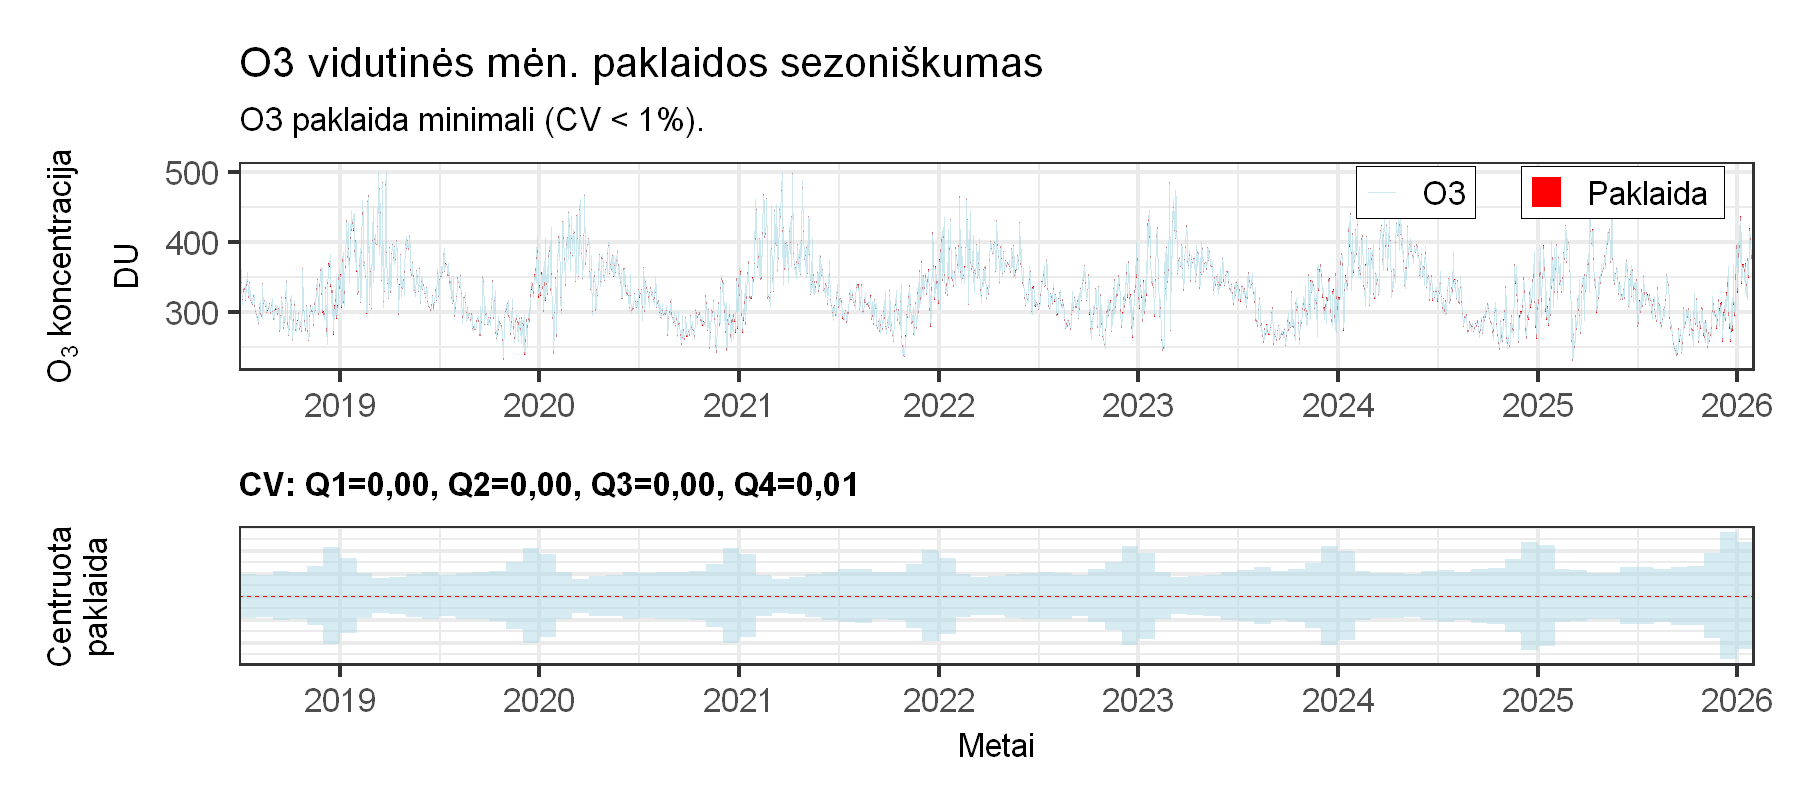

In [106]:
options(repr.plot.width = 6, repr.plot.height = 2.7, repr.plot.res = 300)
gg_final_o3 <- p_O3_error / p_O3_error_avg +
  plot_layout(heights = c(3, 2))

gg_final_o3

ggsave(filename = "gg_final_o3.png", width = 6,
  height = 2.7, units = "in",
  dpi = 300)

# Tendencijos

In [71]:
plot_trend_line <- function(data, var, name) {
  ts_full <- ts(data[[var]], frequency = 365)
  
  ts_clean <- na.contiguous(ts_full)
  decomp <- stl(ts_clean, s.window = "periodic")

  trend_data <- data[!is.na(data[[var]]), ]
  trend_data <- na.contiguous(trend_data[, c("time", var)])
  trend_data$trend <- as.numeric(decomp$time.series[, "trend"])

  min <- min(trend_data$trend)
  max <- max(trend_data$trend)

  min_date <- trend_data |> filter(trend == min) |> 
    pull(time) |> 
    min()

  max_date <- trend_data |> filter(trend == max) |> 
    pull(time) |> 
    min()

  if (abs(max) > abs(min)) {
    ratio = max / min
  } else {
    ratio = min / max
  }

  if (startsWith(name, "$")) {
    y_lab <- parse(text = gsub("\\$", "", name))
  } else {
    y_lab <- name
  }

  fmt <- function(x) gsub("\\.", ",", sprintf("%.2f", x))
  
  p <- ggplot(data, aes(x = time)) +
    geom_line(aes(y = .data[[var]]), alpha = 0.3, color = "gray") +
    geom_line(data = trend_data, aes(x = time, y = trend), color = "blue", linewidth = 0.5) +
    geom_hline(yintercept = min, linewidth = 0.3, linetype = 'dashed', color = 'grey50') +
    geom_hline(yintercept = max, linewidth = 0.3, linetype = 'dashed', color = 'grey50') +
    geom_vline(xintercept = min_date, linewidth = 0.3, color = 'red', alpha = 0.5) +
    geom_vline(xintercept = max_date, linewidth = 0.3, color = 'red', alpha = 0.5) +
    scale_x_date(date_labels = "%Y", date_breaks = "1 year", expand = expansion(mult = 0, add = 0) ) +
    theme_bw() +
    labs(y = y_lab, x = NULL,
    subtitle = paste('min = ',fmt(min), ', max = ', fmt(max), ', santykis = ', fmt(ratio), sep = '')) +
    theme(axis.title.y = element_text(size = 8),
        axis.title.x = element_text(size = 8),
        legend.position = c(0.98, 0.98),
        legend.justification = c("right", "top"),
        legend.background = element_rect(fill = "white", color = "black", linewidth = 0.1),
        legend.box = "horizontal",
        legend.direction = "horizontal",
        legend.margin = margin(2, 2, 2, 2),
        legend.box.margin = margin(0, 0, 0, 0),
        plot.title = element_text(size = 10),
        plot.subtitle = element_text(size = 8),
        legend.text = element_text(size = 8),
        legend.key.size = unit(0.3, "cm"),
        axis.text.x = element_text(size = 6),
        axis.text.y = element_text(size = 8),
        panel.grid = element_blank())

  return(p)
}

In [73]:
p_trend_of_pans <- plot_trend_line(data, "pans", "PANS")
p_trend_of_nmvoc <- plot_trend_line(data, "nmvoc", "NMVOC")
p_trend_of_nh3 <- plot_trend_line(data, "nh3", "$NH[3]$")
p_trend_of_aai <- plot_trend_line(data, "absorbing_aerosol_index", "AAI")

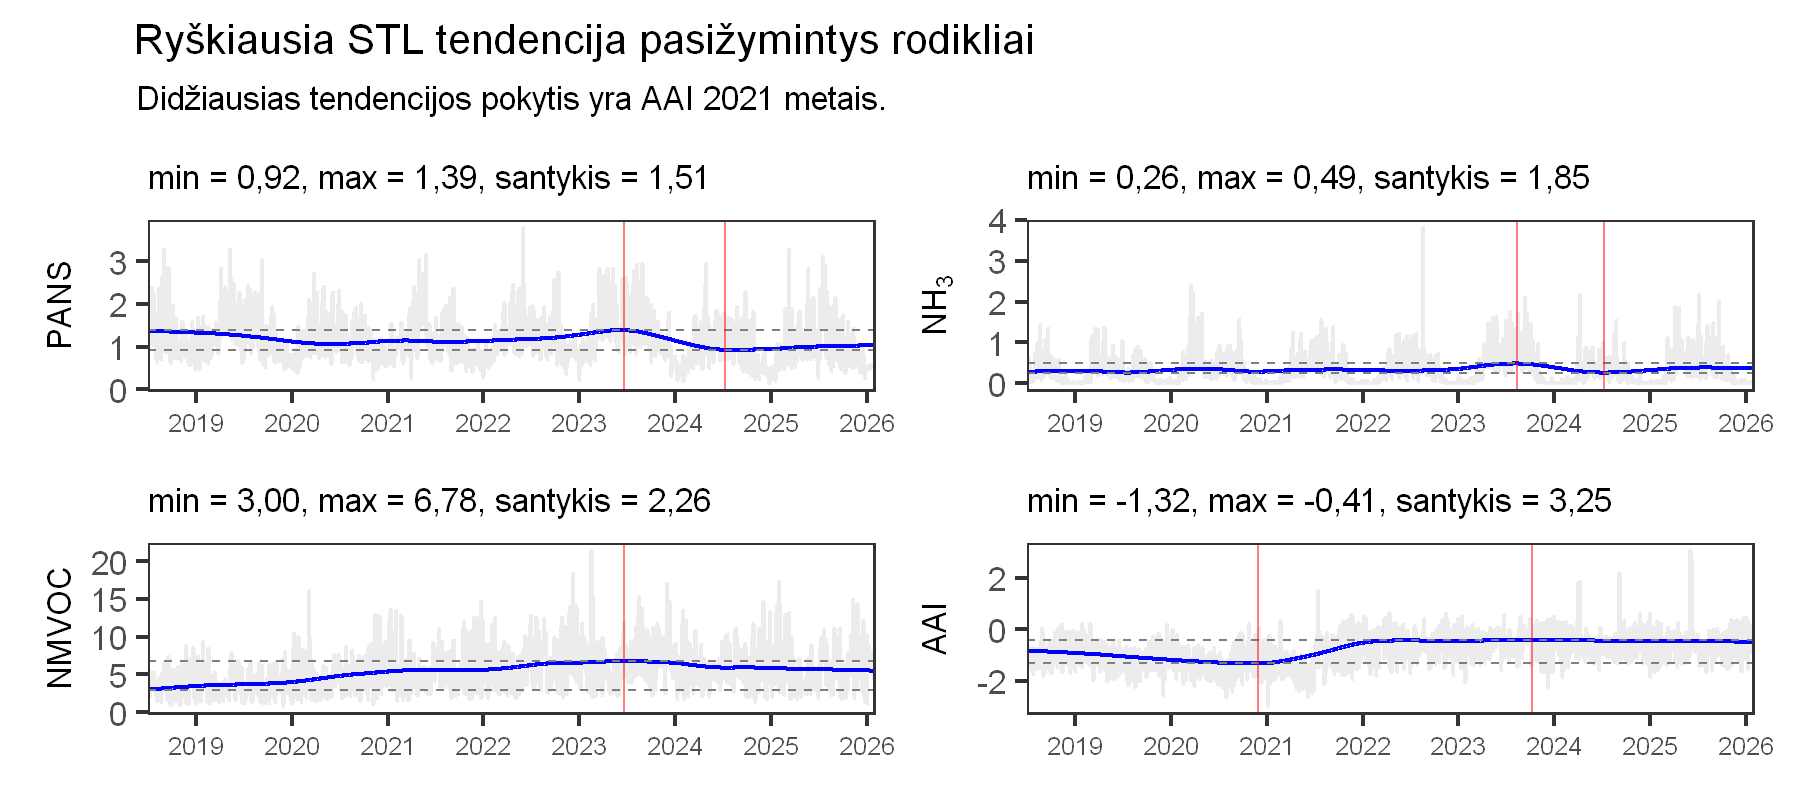

In [82]:
options(repr.plot.width = 6, repr.plot.height = 2.7, repr.plot.res = 300)

gg_tendecy_plot <- (
  p_trend_of_pans / p_trend_of_nmvoc |
  p_trend_of_nh3 / p_trend_of_aai
) +
  plot_annotation(
    title = 'Ryškiausia STL tendencija pasižymintys rodikliai',
    subtitle = 'Didžiausias tendencijos pokytis yra AAI 2021 metais.',
    theme = theme(
      plot.title = element_text(size = 10, hjust = 0.11),
      plot.subtitle = element_text(size = 8, hjust = 0.095)
    )
  )

gg_tendecy_plot

ggsave(filename = "gg_tendecy_plot.png", width = 6,
  height = 2.7, units = "in",
  dpi = 300)

# Meteo vs ECMWF

## Krituliai

Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_col()`)."
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_col()`)."


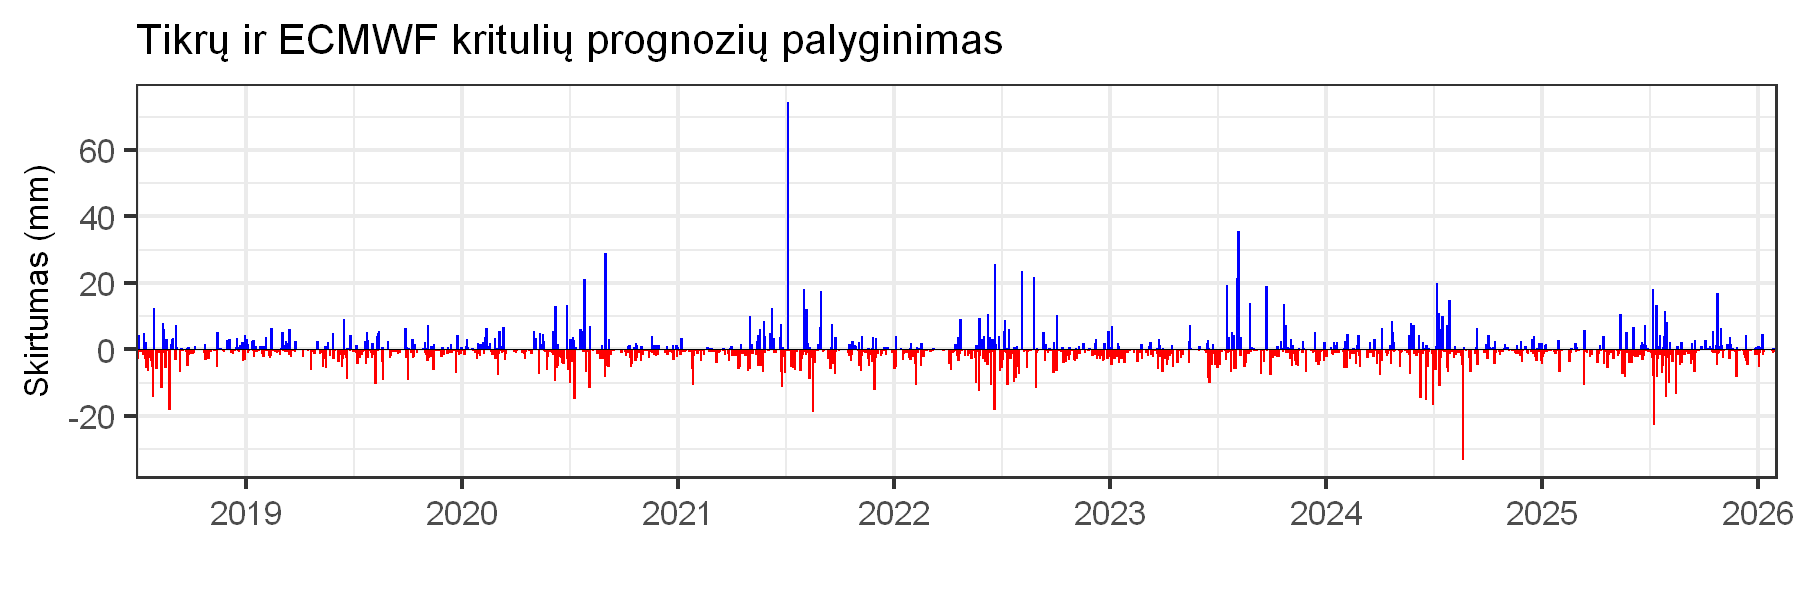

In [31]:
plot_data <- data |>
  mutate(tp_lag = lag(tp, 1))

plot_data <- plot_data |>
  mutate(
    diff = missforest_precipitation - tp_lag,
    direction = ifelse(diff >= 0, "Po", "Virš")
  )

p_tp_vs_tp <- ggplot(plot_data, aes(x = time, y = diff)) +
  geom_col(aes(fill = direction), width = 4.1) +
  geom_hline(yintercept = 0, color = "black", linewidth = 0.18) +
  scale_fill_manual(values = c("Virš" = "red", "Po" = "blue")) +
  scale_x_date(date_labels = "%Y", date_breaks = "1 year", expand = expansion(mult = 0, add = 0) ) +
  theme_bw() +
  theme(axis.title.y = element_text(size = 8),
        axis.title.x = element_text(size = 8),
        legend.position = 'none',
        legend.justification = c("right", "top"),
        legend.background = element_rect(fill = "white", color = "black", linewidth = 0.1),
        legend.box = "horizontal",
        legend.direction = "horizontal",
        legend.margin = margin(1, 2, 1, 2),
        legend.box.margin = margin(0, 0, 0, 0),
        plot.title = element_text(size = 10),
        plot.subtitle = element_text(size = 8),
        legend.text = element_text(size = 8),
        legend.key.size = unit(0.3, "cm"),
        axis.text.x = element_text(size = 8),
        axis.text.y = element_text(size = 8)) +
  labs(title = "Tikrų ir ECMWF kritulių prognozių palyginimas",
  y = "Skirtumas (mm)", x = "")


options(repr.plot.width = 6, repr.plot.height = 2)
p_tp_vs_tp

ggsave(filename = "p_tp_vs_tp.png", width = 6,
  height = 2, units = "in",
  dpi = 300)

In [26]:
plot_data |> filter(diff > 40 | diff < -25) |> select(missforest_precipitation, tp_lag, diff, time)

missforest_precipitation,tp_lag,diff,time
<dbl>,<dbl>,<dbl>,<date>
79.8,5.518426,74.28157,2021-07-06
0.0,33.315384,-33.31538,2024-08-21


In [27]:
df <- plot_data |>
  select(time, missforest_precipitation, tp_lag) |>
  rename(obs = missforest_precipitation,
         mod = tp_lag) |>
  filter(!is.na(obs), !is.na(mod))

mae  <- mean(abs(df$mod - df$obs))
rmse <- sqrt(mean((df$mod - df$obs)^2))
bias <- mean(df$mod - df$obs)
cor <- cor(lag(data$tp, 1), data$missforest_precipitation, method = "spearman", use = "complete.obs")

# mae; rmse; bias; cor

data.frame('MAE' = mae, 'RMSE' = rmse, 'Bias' = bias, 'r' = cor) |> round(4)

MAE,RMSE,Bias,r
<dbl>,<dbl>,<dbl>,<dbl>
1.4421,3.4378,0.3221,0.7338


In [28]:
df_nz <- df |> filter(obs > 0, mod > 0)

quant_obs <- quantile(df_nz$obs, probs = c(0.5, 0.75, 0.9, 0.95, 0.99))
quant_mod <- quantile(df_nz$mod, probs = c(0.5, 0.75, 0.9, 0.95, 0.99))

# quant_obs
# quant_mod

data.frame('Stebetos' = quant_obs, 'ECMWF' = quant_mod) |> round(4) |> t()

,50%,75%,90%,95%,99%
Stebetos,1.8000,4.5250,8.9000,13.2000,25.712
ECMWF,2.2796,5.2193,8.8102,12.7133,24.234


In [29]:
df_sum <- df |>
  mutate(
    obs_cum = cumsum(obs),
    mod_cum = cumsum(mod)
  )


Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_point()`)."
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_point()`)."


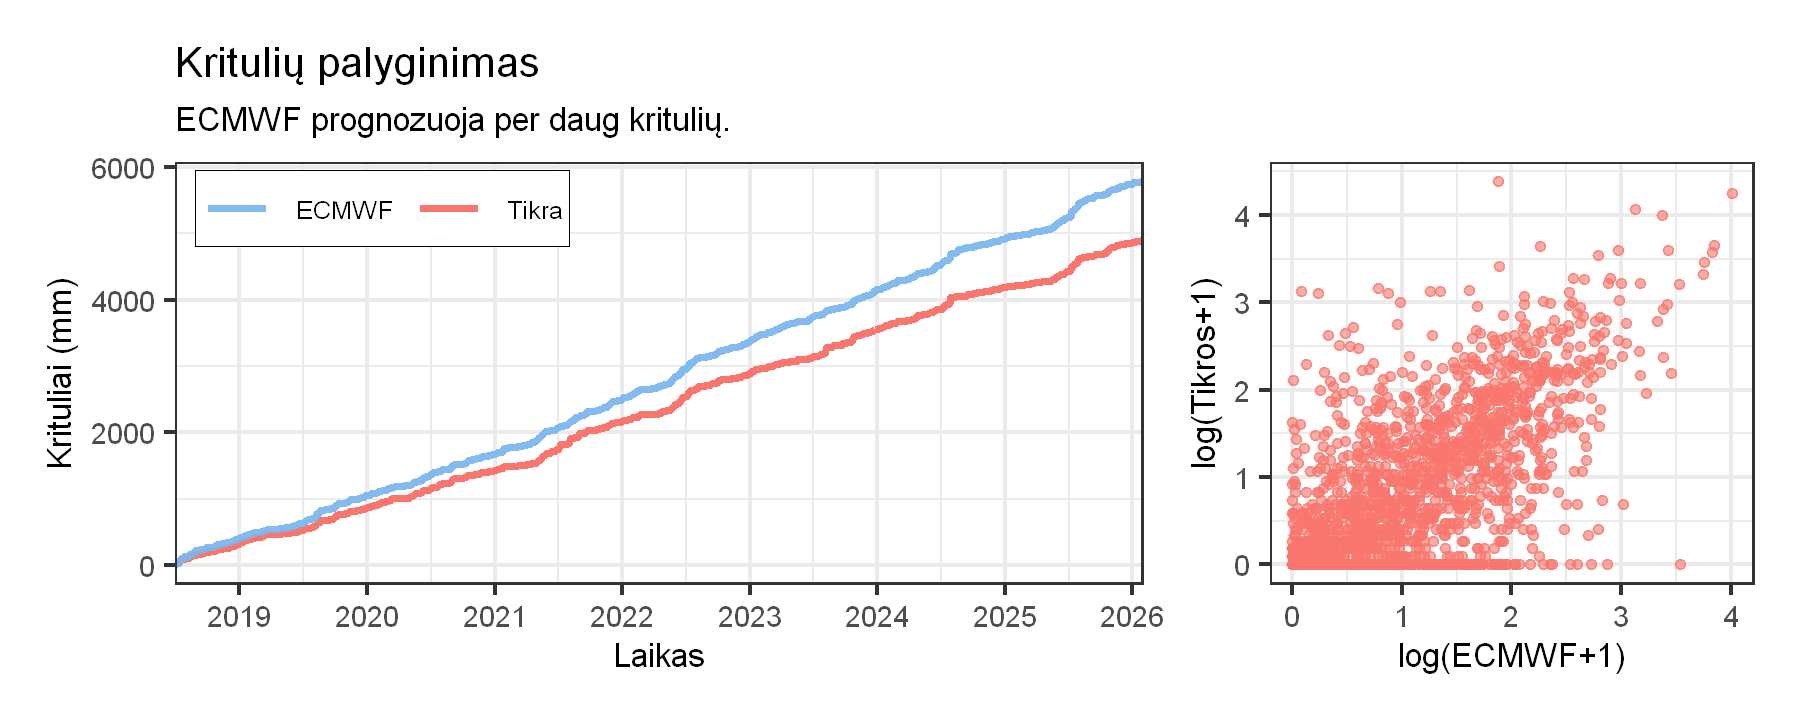

In [48]:
p1 <- ggplot(df_sum, aes(x = time)) +
  geom_line(aes(y = obs_cum, color = "Tikra"), linewidth = 0.8) +
  geom_line(aes(y = mod_cum, color = "ECMWF"), linewidth = 0.8) +
  labs(title = "Kritulių palyginimas", y = "Krituliai (mm)", x = "Laikas", subtitle = "ECMWF prognozuoja per daug kritulių.") +
  scale_color_manual(
    values = c("Tikra" = "#f8766d", "ECMWF" = "#7ab6eeed"),
    name = NULL
  ) +
  scale_x_date(date_labels = "%Y", date_breaks = "1 year", expand = expansion(mult = 0, add = 0) ) +
  theme(axis.title.y = element_text(size = 7),
        axis.title.x = element_text(size = 7),
        plot.title = element_text(size = 10),
        plot.subtitle = element_text(size = 8),
        axis.text.x = element_text(size = 8),
        axis.text.y = element_text(size = 8)) +
  theme_bw()

p2 <- ggplot(data, aes(x = log(lag(tp, 1) + 1), y = log(missforest_precipitation + 1))) +
    geom_point(size = 0.85, alpha = 0.6, color = "#f8766d") +
    theme(axis.title.y = element_text(size = 7),
        axis.title.x = element_text(size = 7),
        plot.title = element_text(size = 10),
        plot.subtitle = element_text(size = 8),
        axis.text.x = element_text(size = 8),
        axis.text.y = element_text(size = 8)) +
    theme_bw() +
    labs(x = 'log(ECMWF+1)', y = "log(Tikros+1)")

options(repr.plot.width = 6, repr.plot.height = 2.4)

p1 + p2 + plot_layout(width = c(2, 1)) &
  theme(legend.position = c(0.02, 0.98),
        legend.justification = c("left", "top"),
        legend.background = element_rect(fill = "white", color = "black", linewidth = 0.1),
        legend.box = "horizontal",
        legend.direction = "horizontal",
        legend.margin = margin(0.5, 1.5, 0.5, 1.5),
        legend.box.margin = margin(0, 0, 0, 0),
        plot.title = element_text(size = 10),
        plot.subtitle = element_text(size=8),
        axis.title.x = element_text(size = 8),
        axis.title.y = element_text(size = 8),
        axis.text.x = element_text(size = 7),
        axis.text.y = element_text(size = 7),
        legend.text = element_text(size = 6))

ggsave(filename = "cumsum_tp.png", width = 6,
  height = 2.4, units = "in",
  dpi = 300)